# Proyecto 2 – Análisis Exploratorio
## Tema 10: Predecir qué respuesta preferirá un usuario en una batalla cara a cara (Chatbot Arena)

Dataset: competencia de Kaggle *LMSYS – Chatbot Arena Human Preference Predictions* (`train.csv`).

Este notebook cubre las actividades **2, 3 y 4** de la guía:

2. Análisis del problema planteado y de los datos
3. Limpieza y preprocesamiento
4. Análisis exploratorio (variables/observaciones, resumen numérico y tablas de frecuencia, cruces y gráficos)

In [1]:
import json, re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", "{:,.3f}".format)

# 2. Análisis del problema y de los datos

## 2.1 Situación problemática

Los modelos de lenguaje (LLM) se evalúan cada vez menos con benchmarks estáticos y cada vez más con **preferencias humanas**. Chatbot Arena (LMSYS) es una plataforma donde un usuario escribe un prompt, dos modelos anónimos responden en paralelo y el usuario vota cuál respuesta prefiere (o declara empate). Con millones de votos se construye un ranking tipo Elo de los modelos.

El problema es que recolectar votos humanos es caro y lento, y además se sabe que las personas tienen sesgos al votar: prefieren respuestas más largas (*verbosity bias*), respuestas con formato (*markdown*, listas, negritas), tienden a favorecer la respuesta que aparece en cierta posición (*position bias*) y a las respuestas que confirman lo que piensan. Un *reward model* entrenado ingenuamente hereda esos sesgos.

## 2.2 Problema científico

Dado un prompt y dos respuestas generadas por dos LLM distintos, **¿es posible predecir qué respuesta preferirá un usuario humano (A, B o empate) a partir del texto de la conversación?**, y ¿qué características de las respuestas (longitud, formato, modelo que la generó, número de turnos, etc.) explican esa preferencia?

## 2.3 Objetivos

**General:** Realizar un análisis exploratorio del conjunto de datos de Chatbot Arena para comprender la estructura de las batallas y los factores asociados a la preferencia humana, como base para un modelo predictivo de preferencia.

**Específicos:**
1. Describir y limpiar el conjunto de datos (variables, observaciones, valores faltantes, duplicados, respuestas nulas) y derivar variables cuantitativas a partir del texto.
2. Cuantificar la relación entre la preferencia del usuario y características medibles de las respuestas: longitud, diferencia de longitud, uso de formato markdown, número de turnos y modelo que responde.
3. Identificar sesgos presentes en los votos (verbosidad, posición, empates) y su magnitud, para decidir qué variables y qué tratamiento del texto usar en la fase de modelado.

## 2.4 Descripción de los datos

Cada fila del `train.csv` es una **batalla**: una conversación (uno o más turnos) enviada a dos modelos, con el voto del usuario.

| Variable | Tipo | Descripción |
|---|---|---|
| `id` | entero | Identificador único de la batalla |
| `model_a`, `model_b` | categórica (texto) | Nombre del modelo que generó cada respuesta |
| `prompt` | texto (lista JSON) | Lista con el/los mensajes del usuario, uno por turno |
| `response_a`, `response_b` | texto (lista JSON) | Lista con la respuesta de cada modelo en cada turno |
| `winner_model_a`, `winner_model_b`, `winner_tie` | binaria (0/1) | Codificación *one-hot* del voto: gana A, gana B o empate |

La variable objetivo es por lo tanto **multiclase con 3 categorías** (A, B, empate). No hay variables numéricas "nativas" además de los indicadores del voto: toda la información predictiva está en el texto y en los nombres de los modelos, por lo que en el preprocesamiento se derivan variables cuantitativas.

In [2]:
# Búsqueda del archivo train.csv en las ubicaciones habituales
candidates = [Path("LMSYS Chatbot Arena/train.csv"), Path("data/train.csv"), Path("train.csv"), Path("../data/train.csv"), Path("/kaggle/input/lmsys-chatbot-arena/train.csv")]
DATA_PATH = next((p for p in candidates if p.exists()), None)
assert DATA_PATH is not None, "No se encontró train.csv"
print("Usando:", DATA_PATH)

raw = pd.read_csv(DATA_PATH)
print("Filas x columnas:", raw.shape)
raw.head(3)

Usando: data/train.csv


Filas x columnas: (57477, 9)


,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain percentage of females on managerial positions?"",""OK, does pineapple b...","[""The question of whether it is morally right to aim for a certain percentage of females in managerial positions is ...","[""As an AI, I don't have personal beliefs or opinions. However, I can tell you that the question of gender quotas in...",1,0,0
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage license and marriage certificate?"",""How can I get both of them as quick as...","[""A marriage license is a legal document that allows a couple to get married. It is issued by a government agency, s...","[""A marriage license and a marriage certificate are two different legal documents that have separate purposes.\n\n1....",0,1,0
2,65089,gpt-3.5-turbo-0613,mistral-medium,"[""explain function calling. how would you call a function?""]","[""Function calling is the process of invoking or executing a function in a programming language. To call a function,...","[""Function calling is the process of invoking a function in a program. A function is a block of code that performs a...",0,0,1


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 57477 entries, 0 to 57476
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   id              57477 non-null  int64
 1   model_a         57477 non-null  str  
 2   model_b         57477 non-null  str  
 3   prompt          57477 non-null  str  
 4   response_a      57477 non-null  str  
 5   response_b      57477 non-null  str  
 6   winner_model_a  57477 non-null  int64
 7   winner_model_b  57477 non-null  int64
 8   winner_tie      57477 non-null  int64
dtypes: int64(4), str(5)
memory usage: 3.9 MB


In [4]:
# Ejemplo de una batalla completa
ej = raw.iloc[0]
print("Modelo A:", ej.model_a, "| Modelo B:", ej.model_b)
print("\nPROMPT:", json.loads(ej.prompt)[0][:500])
print("\nRESPUESTA A:", str(json.loads(ej.response_a)[0])[:500])
print("\nRESPUESTA B:", str(json.loads(ej.response_b)[0])[:500])
print("\nVoto -> A:", ej.winner_model_a, " B:", ej.winner_model_b, " Empate:", ej.winner_tie)

Modelo A: gpt-4-1106-preview | Modelo B: gpt-4-0613

PROMPT: Is it morally right to try to have a certain percentage of females on managerial positions?

RESPUESTA A: The question of whether it is morally right to aim for a certain percentage of females in managerial positions is a complex ethical issue that involves considerations of fairness, equality, diversity, and discrimination.

Here are some arguments in favor of and against such policies:

**Arguments in favor:**

1. **Correcting Historical Inequities:** Women have historically been underrepresented in leadership roles due to various cultural, institutional, and social barriers. Aiming for a specific

RESPUESTA B: As an AI, I don't have personal beliefs or opinions. However, I can tell you that the question of gender quotas in managerial positions is a complex one and positions can vary. Advocates argue that such measures can help correct historical imbalances, promote diversity, and may lead to better decision-making. Critics

# 3. Limpieza y preprocesamiento

Tareas realizadas:

1. **Verificación de integridad**: valores faltantes por columna, `id` duplicados y filas duplicadas.
2. **Consistencia del objetivo**: comprobar que exactamente uno de `winner_model_a`, `winner_model_b`, `winner_tie` es 1 en cada fila, y construir una sola variable categórica `winner` ∈ {A, B, tie}.
3. **Decodificación del texto**: `prompt`, `response_a` y `response_b` están almacenados como cadenas JSON con una lista por turno. Se decodifican a listas de Python; los turnos con respuesta `null` (el modelo no contestó) se detectan y se cuentan.
4. **Consistencia de turnos**: el número de elementos de `prompt`, `response_a` y `response_b` debe coincidir.
5. **Ingeniería de variables cuantitativas** a partir del texto (por batalla, sumando todos los turnos):
   - `n_turns`: número de turnos de la conversación
   - `prompt_len`, `len_a`, `len_b`: longitud en caracteres; `words_a`, `words_b`: número de palabras
   - `len_diff = len_a − len_b`, `len_ratio = len_a / len_b`
   - Indicadores de formato: número de bloques de código, ítems de lista, encabezados y negritas (` ``` `, `- `/`1. `, `#`, `**`)
   - `null_a`, `null_b`: la respuesta es nula/vacía en al menos un turno
   - `same_model`: A y B son el mismo modelo
   - `family_a`, `family_b`: familia del modelo (gpt-4, claude, llama, mistral, gemini, …) para reducir cardinalidad
6. **Tratamiento de faltantes/atípicos**: no se eliminan batallas por longitud; las respuestas nulas se conservan como indicador (son informativas: casi siempre pierden). Se eliminan únicamente duplicados exactos si existen.

In [5]:
df = raw.copy()

print("Valores faltantes por columna:")
print(df.isna().sum())
print("\nids duplicados:", df["id"].duplicated().sum())
print("Filas duplicadas (sin id):", df.drop(columns="id").duplicated().sum())

# Consistencia del objetivo
suma = df[["winner_model_a", "winner_model_b", "winner_tie"]].sum(axis=1)
print("\nFilas con exactamente un ganador:", (suma == 1).sum(), "de", len(df))

df = df.drop_duplicates(subset=df.columns.difference(["id"]).tolist()).reset_index(drop=True)
df["winner"] = np.select([df.winner_model_a == 1, df.winner_model_b == 1], ["A", "B"], default="tie")
df["winner"] = pd.Categorical(df["winner"], categories=["A", "B", "tie"])
print("\nDistribución del objetivo:\n", df["winner"].value_counts())

Valores faltantes por columna:
id                0
model_a           0
model_b           0
prompt            0
response_a        0
response_b        0
winner_model_a    0
winner_model_b    0
winner_tie        0
dtype: int64

ids duplicados: 0


Filas duplicadas (sin id): 7

Filas con exactamente un ganador: 57477 de 57477



Distribución del objetivo:
 winner
A      20063
B      19649
tie    17758
Name: count, dtype: int64


In [6]:
def decode(s):
    """Decodifica la lista JSON; devuelve lista de str (None -> '')."""
    try:
        lst = json.loads(s)
    except Exception:
        return [str(s)]
    return [("" if x is None else str(x)) for x in lst]

def count_nulls(s):
    try:
        return sum(1 for x in json.loads(s) if x is None or str(x).strip() == "")
    except Exception:
        return 0

for c in ["prompt", "response_a", "response_b"]:
    df[c + "_list"] = df[c].map(decode)
    df[c + "_text"] = df[c + "_list"].map(lambda l: "\n".join(l))

df["n_turns"] = df["prompt_list"].map(len)
df["turns_consistent"] = (df["response_a_list"].map(len) == df["n_turns"]) & (df["response_b_list"].map(len) == df["n_turns"])
print("Batallas con número de turnos consistente:", df["turns_consistent"].mean().round(4))

df["null_a"] = df["response_a"].map(count_nulls) > 0
df["null_b"] = df["response_b"].map(count_nulls) > 0
print("Batallas con alguna respuesta nula/vacía -> A:", df.null_a.sum(), " B:", df.null_b.sum())

Batallas con número de turnos consistente: 1.0


Batallas con alguna respuesta nula/vacía -> A: 133  B: 143


In [7]:
# Variables cuantitativas derivadas del texto
re_code   = re.compile(r"```")
re_list   = re.compile(r"^\s*(?:[-*•]|\d+[.)])\s+", re.M)
re_header = re.compile(r"^\s*#{1,6}\s+", re.M)
re_bold   = re.compile(r"\*\*[^*]+\*\*")

def text_feats(t):
    return dict(len=len(t), words=len(t.split()),
                code=len(re_code.findall(t)) // 2, lists=len(re_list.findall(t)),
                headers=len(re_header.findall(t)), bold=len(re_bold.findall(t)))

for side in ["a", "b"]:
    f = pd.DataFrame(df[f"response_{side}_text"].map(text_feats).tolist())
    for col in f.columns:
        df[f"{col}_{side}"] = f[col].values
df["prompt_len"] = df["prompt_text"].str.len()
df["prompt_words"] = df["prompt_text"].str.split().str.len()

df["len_diff"]  = df["len_a"] - df["len_b"]
df["len_ratio"] = (df["len_a"] + 1) / (df["len_b"] + 1)
df["fmt_a"] = df[["code_a", "lists_a", "headers_a", "bold_a"]].sum(axis=1)
df["fmt_b"] = df[["code_b", "lists_b", "headers_b", "bold_b"]].sum(axis=1)
df["same_model"] = df["model_a"] == df["model_b"]

def family(m):
    m = m.lower()
    for key in ["gpt-4", "gpt-3.5", "claude", "gemini", "llama", "mistral", "mixtral", "qwen", "yi-", "vicuna", "palm", "command", "tulu", "zephyr", "starling", "openchat", "wizardlm", "koala", "alpaca", "dolly", "falcon", "chatglm", "stablelm", "solar", "deepseek", "pplx", "openhermes", "nous", "oasst", "dolphin", "gemma", "phi", "guanaco", "mpt", "rwkv", "fastchat", "stripedhyena", "llama2", "codellama", "dbrx", "snowflake", "reka", "olmo"]:
        if key in m:
            return key.rstrip("-")
    return "otro"

df["family_a"] = df["model_a"].map(family)
df["family_b"] = df["model_b"].map(family)

num_cols = ["n_turns", "prompt_len", "prompt_words", "len_a", "len_b", "words_a", "words_b",
            "len_diff", "len_ratio", "code_a", "code_b", "lists_a", "lists_b",
            "headers_a", "headers_b", "bold_a", "bold_b", "fmt_a", "fmt_b"]
cat_cols = ["winner", "model_a", "model_b", "family_a", "family_b", "same_model", "null_a", "null_b"]
df[num_cols + cat_cols].head()

,n_turns,prompt_len,prompt_words,len_a,len_b,words_a,words_b,len_diff,len_ratio,code_a,...,fmt_a,fmt_b,winner,model_a,model_b,family_a,family_b,same_model,null_a,null_b
0,2,159,29,4459,1200,674,205,3259,3.714,0,...,20,0,A,gpt-4-1106-preview,gpt-4-0613,gpt-4,gpt-4,False,False,False
1,3,192,36,3096,3592,539,579,-496,0.862,0,...,3,15,B,koala-13b,gpt-4-0613,koala,gpt-4,False,False,False
2,1,56,9,884,1790,147,297,-906,0.494,1,...,3,2,tie,gpt-3.5-turbo-0613,mistral-medium,gpt-3.5,mistral,False,False,False
3,1,83,18,3165,1550,547,271,1615,2.041,0,...,10,5,A,llama-2-13b-chat,mistral-7b-instruct,llama,mistral,False,False,False
4,1,75,14,1290,760,234,124,530,1.696,0,...,3,0,B,koala-13b,gpt-3.5-turbo-0314,koala,gpt-3.5,False,False,False


# 4. Análisis exploratorio

## 4.a Variables y observaciones

Se distinguen las variables **originales** del archivo y las **derivadas** en el preprocesamiento.

In [8]:
print(f"Observaciones (batallas): {len(df):,}")
print(f"Variables originales: {raw.shape[1]}  |  Variables tras preprocesamiento: {df.shape[1]}")

tipos = pd.DataFrame({
    "variable": raw.columns,
    "dtype": raw.dtypes.astype(str).values,
    "tipo_estadístico": ["identificador", "categórica nominal", "categórica nominal", "texto", "texto", "texto",
                         "binaria (objetivo)", "binaria (objetivo)", "binaria (objetivo)"],
    "valores_únicos": [raw[c].nunique() for c in raw.columns],
})
tipos

Observaciones (batallas): 57,470
Variables originales: 9  |  Variables tras preprocesamiento: 41


,variable,dtype,tipo_estadístico,valores_únicos
0,id,int64,identificador,57477
1,model_a,str,categórica nominal,64
2,model_b,str,categórica nominal,64
3,prompt,str,texto,51734
4,response_a,str,texto,56566
5,response_b,str,texto,56609
6,winner_model_a,int64,binaria (objetivo),2
7,winner_model_b,int64,binaria (objetivo),2
8,winner_tie,int64,binaria (objetivo),2


In [9]:
derivadas = pd.DataFrame({
    "variable": num_cols + cat_cols,
    "dtype": df[num_cols + cat_cols].dtypes.astype(str).values,
    "tipo_estadístico": ["cuantitativa discreta"] + ["cuantitativa"] * 6 + ["cuantitativa (diferencia)", "cuantitativa (razón)"] + ["cuantitativa discreta"] * 10
                        + ["categórica (objetivo, 3 clases)", "categórica nominal", "categórica nominal", "categórica nominal", "categórica nominal", "binaria", "binaria", "binaria"],
})
derivadas

,variable,dtype,tipo_estadístico
0,n_turns,int64,cuantitativa discreta
1,prompt_len,int64,cuantitativa
2,prompt_words,int64,cuantitativa
3,len_a,int64,cuantitativa
4,len_b,int64,cuantitativa
5,words_a,int64,cuantitativa
6,words_b,int64,cuantitativa
7,len_diff,int64,cuantitativa (diferencia)
8,len_ratio,float64,cuantitativa (razón)
9,code_a,int64,cuantitativa discreta


## 4.b Resumen de variables numéricas y tablas de frecuencia

In [10]:
resumen = df[num_cols].describe(percentiles=[.05, .25, .5, .75, .95, .99]).T
resumen["cv"] = resumen["std"] / resumen["mean"]
resumen["skew"] = df[num_cols].skew()
resumen

,count,mean,std,min,5%,25%,50%,75%,95%,99%,max,cv,skew
n_turns,"57,470.000",1.244,0.908,1.000,1.000,1.000,1.000,1.000,2.000,5.000,36.000,0.730,9.236
prompt_len,"57,470.000",352.363,"1,025.429",3.000,20.000,48.000,91.000,233.000,"1,419.000","4,701.400","32,833.000",2.910,8.579
prompt_words,"57,470.000",56.222,151.624,1.000,4.000,9.000,16.000,41.000,228.550,666.000,"4,809.000",2.697,8.787
len_a,"57,470.000","1,330.529","1,461.928",0.000,61.000,391.000,"1,036.000","1,810.000","3,584.000","6,783.930","53,299.000",1.099,5.009
len_b,"57,470.000","1,337.335","1,483.808",0.000,60.000,396.000,"1,044.000","1,819.000","3,575.550","6,736.310","52,402.000",1.110,5.523
words_a,"57,470.000",212.357,226.285,0.000,10.000,66.000,169.000,290.000,559.000,"1,034.000","9,184.000",1.066,5.166
words_b,"57,470.000",213.198,228.551,0.000,10.000,67.000,171.000,291.000,559.000,"1,048.310","8,173.000",1.072,5.479
len_diff,"57,470.000",-6.807,"1,061.058","-51,223.000","-1,470.550",-413.000,0.000,405.000,"1,449.000","2,748.310","43,003.000",-155.885,-1.098
len_ratio,"57,470.000",2.478,31.554,0.000,0.183,0.625,1.000,1.586,5.426,21.565,"4,825.000",12.731,104.428
code_a,"57,470.000",0.198,1.388,0.000,0.000,0.000,0.000,0.000,1.000,4.000,263.000,7.029,119.926


In [11]:
# Tablas de frecuencia y proporciones: objetivo y variables binarias
def freq(s, name=None):
    t = pd.concat([s.value_counts(), s.value_counts(normalize=True).round(4)], axis=1)
    t.columns = ["frecuencia", "proporción"]
    t.index.name = name or s.name
    return t

display(freq(df["winner"]))
display(freq(df["n_turns"].clip(upper=10).astype(str).replace("10", "10+"), "n_turns"))
display(freq(df["same_model"]))
display(freq(df["null_a"]))
display(freq(df["null_b"]))

,frecuencia,proporción
winner,,
A,20063,0.349
B,19649,0.342
tie,17758,0.309


,frecuencia,proporción
n_turns,,
1,49932,0.869
2,4672,0.081
3,1485,0.026
4,607,0.011
5,311,0.005
6,167,0.003
7,103,0.002
10+,89,0.002
8,60,0.001


,frecuencia,proporción
same_model,,
False,57470,1.000


,frecuencia,proporción
null_a,,
False,57337,0.998
True,133,0.002


,frecuencia,proporción
null_b,,
False,57327,0.998
True,143,0.003


In [12]:
# Frecuencia de modelos (apariciones como A o como B)
modelos = pd.concat([df["model_a"], df["model_b"]])
print("Modelos distintos:", modelos.nunique())
tabla_modelos = freq(modelos, "modelo")
display(tabla_modelos.head(20))
print("Los 20 modelos más frecuentes concentran el", round(tabla_modelos["proporción"].head(20).sum()*100, 1), "% de las apariciones")

Modelos distintos: 64


,frecuencia,proporción
modelo,,
gpt-4-1106-preview,7386,0.064
gpt-3.5-turbo-0613,7080,0.062
gpt-4-0613,6164,0.054
claude-2.1,5583,0.049
claude-instant-1,4134,0.036
gpt-4-0314,4122,0.036
claude-1,3978,0.035
vicuna-33b,3720,0.032
mixtral-8x7b-instruct-v0.1,3545,0.031


Los 20 modelos más frecuentes concentran el 64.2 % de las apariciones


In [13]:
familias = pd.concat([df["family_a"], df["family_b"]])
freq(familias, "familia")

,frecuencia,proporción
familia,,
gpt-4,18832,0.164
claude,16150,0.141
gpt-3.5,12595,0.110
llama,10514,0.091
vicuna,8758,0.076
mistral,6357,0.055
mixtral,3870,0.034
wizardlm,3223,0.028
gemini,2923,0.025


**Hallazgos de 4.a y 4.b**

- 57,477 batallas y 9 variables originales; tras eliminar 7 duplicados exactos quedan 57,470. No hay valores faltantes y cada fila tiene exactamente un voto.
- El objetivo está **balanceado**: A 34.9 %, B 34.2 %, empate 30.9 %. Un modelo trivial acierta ~35 %, y el empate es una clase tan grande como las otras dos, lo que hace el problema más difícil que una comparación binaria.
- El 86.9 % de las conversaciones tiene un solo turno; la cola llega a 36 turnos.
- Las longitudes son muy asimétricas (log-normales): mediana de ~1,040 caracteres por respuesta con máximos de más de 50,000; el prompt tiene mediana de 91 caracteres. Por eso los gráficos usan escala logarítmica y las medidas de resumen se basan en medianas y percentiles.
- `len_a` y `len_b` tienen distribuciones prácticamente idénticas (media ~1,330, mediana ~1,040), consistente con la asignación aleatoria de modelos a las posiciones.
- Los indicadores de formato tienen mediana 0 (la mayoría de respuestas no usa markdown) pero colas largas (hasta 263 bloques de código).
- 64 modelos distintos, con distribución muy desigual: los 20 más frecuentes concentran el 64 % de apariciones y las familias GPT‑4, Claude y GPT‑3.5 suman el 41 %. No hay batallas de un modelo contra sí mismo.
- Respuestas nulas/vacías en ~0.2 % de las batallas por lado.

## 4.c Cruce de variables

Las preguntas clave son: **¿la longitud, el formato, la posición y el modelo explican el voto?**

In [14]:
# Longitud y formato de cada respuesta según el resultado
cruce = df.groupby("winner")[["len_a", "len_b", "words_a", "words_b", "fmt_a", "fmt_b", "n_turns", "prompt_len"]].agg(["median", "mean"]).round(1)
cruce

len_a               len_b           words_a         words_b  \
          median      mean    median      mean  median    mean  median   
winner                                                                   
A      1,241.000 1,515.500   961.000 1,266.500 201.000 240.800 158.000   
B        943.000 1,246.400 1,259.000 1,515.900 153.000 199.100 203.000   
tie      890.000 1,214.600   888.000 1,219.700 149.000 195.000 148.000   

                fmt_a        fmt_b       n_turns       prompt_len          
          mean median  mean median  mean  median  mean     median    mean  
winner                                                                     
A      202.100  0.000 5.400  0.000 4.000   1.000 1.300     89.000 348.700  
B      240.500  0.000 4.100  0.000 5.300   1.000 1.300     89.000 341.200  
tie    195.500  0.000 4.000  0.000 4.000   1.000 1.200     95.000 368.900

In [15]:
# Sesgo de verbosidad: probabilidad de ganar según quién es más largo
df["longer"] = np.select([df.len_a > df.len_b, df.len_a < df.len_b], ["A más larga", "B más larga"], default="Igual")
ct = pd.crosstab(df["longer"], df["winner"], normalize="index").round(3)
display(ct)

# Porcentaje de victorias (excluyendo empates) de la respuesta más larga
sin_tie = df[df.winner != "tie"]
gana_larga = ((sin_tie.len_a > sin_tie.len_b) & (sin_tie.winner == "A")) | ((sin_tie.len_b > sin_tie.len_a) & (sin_tie.winner == "B"))
print(f"En batallas sin empate, la respuesta más larga gana el {gana_larga.mean()*100:.1f} % de las veces")

winner,A,B,tie
longer,,,
A más larga,0.431,0.263,0.306
B más larga,0.270,0.425,0.305
Igual,0.145,0.108,0.747


En batallas sin empate, la respuesta más larga gana el 61.5 % de las veces


In [16]:
# Tasa de victoria de la respuesta más larga en función de la magnitud de la diferencia (razón de longitud)
sin_tie = df[(df.winner != "tie")].copy()
sin_tie["ratio_larga"] = np.maximum(sin_tie.len_ratio, 1 / sin_tie.len_ratio)
sin_tie["gana_larga"] = gana_larga[sin_tie.index]
bins = [1, 1.1, 1.25, 1.5, 2, 3, 5, np.inf]
sin_tie["ratio_bin"] = pd.cut(sin_tie["ratio_larga"], bins, right=False)
tabla_ratio = sin_tie.groupby("ratio_bin")["gana_larga"].agg(["mean", "size"]).rename(columns={"mean": "p(gana la más larga)", "size": "n"})
tabla_ratio

,p(gana la más larga),n
ratio_bin,,
"[1.0, 1.1)",0.495,4759
"[1.1, 1.25)",0.547,5535
"[1.25, 1.5)",0.594,6612
"[1.5, 2.0)",0.638,7673
"[2.0, 3.0)",0.663,6241
"[3.0, 5.0)",0.677,4150
"[5.0, inf)",0.687,4742


In [17]:
# Empates según diferencia de longitud y según número de turnos
df["abs_ratio_bin"] = pd.cut(np.maximum(df.len_ratio, 1/df.len_ratio), bins, right=False)
display(df.groupby("abs_ratio_bin")["winner"].value_counts(normalize=True).unstack().round(3))
display(pd.crosstab(df["n_turns"].clip(upper=5), df["winner"], normalize="index").round(3))

winner,A,B,tie
abs_ratio_bin,,,
"[1.0, 1.1)",0.316,0.307,0.377
"[1.1, 1.25)",0.329,0.321,0.350
"[1.25, 1.5)",0.343,0.326,0.330
"[1.5, 2.0)",0.357,0.352,0.291
"[2.0, 3.0)",0.367,0.357,0.276
"[3.0, 5.0)",0.366,0.369,0.264
"[5.0, inf)",0.371,0.374,0.256


winner,A,B,tie
n_turns,,,
1,0.347,0.340,0.313
2,0.370,0.347,0.284
3,0.353,0.360,0.287
4,0.356,0.379,0.265
5,0.368,0.363,0.269


In [18]:
# Sesgo de formato: ¿gana la respuesta con más elementos de formato markdown?
df["more_fmt"] = np.select([df.fmt_a > df.fmt_b, df.fmt_a < df.fmt_b], ["A más formato", "B más formato"], default="Igual")
display(pd.crosstab(df["more_fmt"], df["winner"], normalize="index").round(3))

# Respuestas nulas
display(pd.crosstab(df["null_a"], df["winner"], normalize="index").round(3))
display(pd.crosstab(df["null_b"], df["winner"], normalize="index").round(3))

winner,A,B,tie
more_fmt,,,
A más formato,0.459,0.264,0.277
B más formato,0.269,0.452,0.280
Igual,0.334,0.326,0.340


winner,A,B,tie
null_a,,,
False,0.349,0.342,0.309
True,0.278,0.398,0.323


winner,A,B,tie
null_b,,,
False,0.349,0.342,0.309
True,0.455,0.252,0.294


In [19]:
# Sesgo de posición. Como los modelos se asignan al azar a las posiciones A y B, si no hubiera sesgo
# P(gana A) = P(gana B). Se compara con una prueba binomial (sin empates).
from scipy.stats import binomtest
print("Batallas con el mismo modelo en A y B:", df.same_model.sum(), "(no hay, así que no se puede medir de esa forma)")
nA, nB = (df.winner == "A").sum(), (df.winner == "B").sum()
res = binomtest(int(nA), int(nA + nB), 0.5)
print(f"Gana A: {nA:,} ({nA/(nA+nB):.3%})  |  Gana B: {nB:,} ({nB/(nA+nB):.3%})  |  p-valor binomial = {res.pvalue:.3f}")

# ¿Los modelos aparecen igual de veces en A que en B?
pos = pd.concat([df.model_a.value_counts().rename("A"), df.model_b.value_counts().rename("B")], axis=1)
pos["dif_rel"] = (pos.A - pos.B) / (pos.A + pos.B)
print("Máxima diferencia relativa de apariciones A vs B por modelo:", round(pos.dif_rel.abs().max(), 3))

Batallas con el mismo modelo en A y B: 0 (no hay, así que no se puede medir de esa forma)
Gana A: 20,063 (50.521%)  |  Gana B: 19,649 (49.479%)  |  p-valor binomial = 0.038
Máxima diferencia relativa de apariciones A vs B por modelo: 0.115


**Hallazgos del cruce de variables**

- *Verbosidad*: cuando una respuesta es más larga que la otra, gana en ~43 % de los casos frente a ~27 % de la más corta; excluyendo empates, la respuesta más larga gana el 61.5 % de las veces y la probabilidad crece monótonamente con la razón de longitudes (49.5 % si son casi iguales → 68.7 % si una es 5 veces más larga). La correlación de Spearman de `len_diff` con el objetivo (0.24) es la más alta de todas las variables derivadas.
- *Empates*: son más frecuentes cuando las respuestas tienen longitud parecida (37.7 % con razón < 1.1) y, sobre todo, cuando la longitud es idéntica (74.7 % de empates), lo que suele corresponder a respuestas iguales o ambas vacías. Los empates bajan al 25–26 % cuando una respuesta es mucho más larga y también bajan con más turnos.
- *Formato*: la respuesta con más elementos markdown (listas, negritas, encabezados, código) gana ~45–46 % vs ~26–27 %. Está correlacionado con la longitud, por lo que habrá que separar ambos efectos en el modelado.
- *Respuestas nulas*: son raras (0.2 %) pero cuando A es nula, B gana el 40 % y A solo el 28 %; simétrico para B. Aun así hay ~30 % de empates, lo que indica ruido en el etiquetado.
- *Posición*: A gana 34.9 % y B 34.2 % del total (50.5 % vs 49.5 % de las batallas decididas). La prueba binomial da p = 0.038: hay una ligera ventaja de la posición A estadísticamente detectable, pero de magnitud muy pequeña comparada con el efecto de la longitud.
- *Modelo*: la tasa de victoria sin empates va de ~0.76 (gpt-4-1106-preview) a ~0.3 en los modelos pequeños; la identidad del modelo es muy informativa, pero **no está disponible en el test** de la competencia, así que solo sirve como variable de análisis. La longitud mediana del modelo correlaciona con su tasa de victoria (Spearman 0.59), aunque hay excepciones como gpt-3.5-turbo-0314, muy conciso y con alta tasa de victoria.

In [20]:
# Tasa de victoria por modelo (vista desde A y desde B, combinadas)
a = df[["model_a", "winner"]].rename(columns={"model_a": "modelo"}); a["gana"] = (a.winner == "A"); a["empata"] = (a.winner == "tie")
b = df[["model_b", "winner"]].rename(columns={"model_b": "modelo"}); b["gana"] = (b.winner == "B"); b["empata"] = (b.winner == "tie")
apar = pd.concat([a, b])
winrate = apar.groupby("modelo").agg(batallas=("gana", "size"), tasa_victoria=("gana", "mean"), tasa_empate=("empata", "mean"))
winrate["tasa_victoria_sin_empates"] = winrate.tasa_victoria / (1 - winrate.tasa_empate)
winrate = winrate[winrate.batallas >= 300].sort_values("tasa_victoria_sin_empates", ascending=False).round(3)
winrate

,batallas,tasa_victoria,tasa_empate,tasa_victoria_sin_empates
modelo,,,,
gpt-4-1106-preview,7386,0.551,0.274,0.760
gpt-4-0125-preview,1160,0.514,0.312,0.747
gpt-3.5-turbo-0314,1302,0.546,0.257,0.735
gpt-4-0314,4122,0.484,0.291,0.682
claude-1,3978,0.439,0.298,0.626
qwen1.5-72b-chat,551,0.390,0.328,0.581
gpt-4-0613,6164,0.397,0.302,0.569
claude-instant-1,4134,0.397,0.293,0.562
llama-2-70b-chat,3427,0.373,0.324,0.552


In [21]:
# Longitud media de respuesta por modelo vs tasa de victoria
len_modelo = pd.concat([df[["model_a", "len_a"]].set_axis(["modelo", "len"], axis=1),
                        df[["model_b", "len_b"]].set_axis(["modelo", "len"], axis=1)]).groupby("modelo")["len"].median()
winrate["long_mediana"] = len_modelo
print("Correlación (Spearman) entre longitud mediana del modelo y su tasa de victoria:",
      round(winrate[["long_mediana", "tasa_victoria_sin_empates"]].corr(method="spearman").iloc[0, 1], 3))
winrate[["batallas", "tasa_victoria_sin_empates", "long_mediana"]].head(15)

Correlación (Spearman) entre longitud mediana del modelo y su tasa de victoria: 0.589


,batallas,tasa_victoria_sin_empates,long_mediana
modelo,,,
gpt-4-1106-preview,7386,0.760,"1,886.500"
gpt-4-0125-preview,1160,0.747,"2,254.500"
gpt-3.5-turbo-0314,1302,0.735,516.000
gpt-4-0314,4122,0.682,862.000
claude-1,3978,0.626,"1,299.000"
qwen1.5-72b-chat,551,0.581,"1,483.000"
gpt-4-0613,6164,0.569,889.500
claude-instant-1,4134,0.562,"1,100.500"
llama-2-70b-chat,3427,0.552,"1,556.000"


In [22]:
# Correlaciones entre las variables numéricas y con el objetivo (codificado A=1, tie=0, B=-1)
df["target_num"] = df["winner"].map({"A": 1, "tie": 0, "B": -1}).astype(float)
corr_cols = ["len_a", "len_b", "len_diff", "len_ratio", "words_a", "words_b", "fmt_a", "fmt_b", "n_turns", "prompt_len", "target_num"]
corr = df[corr_cols].corr(method="spearman")
corr["target_num"].drop("target_num").sort_values()

words_b      -0.094
len_b        -0.094
fmt_b        -0.081
n_turns       0.002
prompt_len    0.002
fmt_a         0.080
len_a         0.099
words_a       0.100
len_ratio     0.222
len_diff      0.241
Name: target_num, dtype: float64

## 4.d Gráficos exploratorios

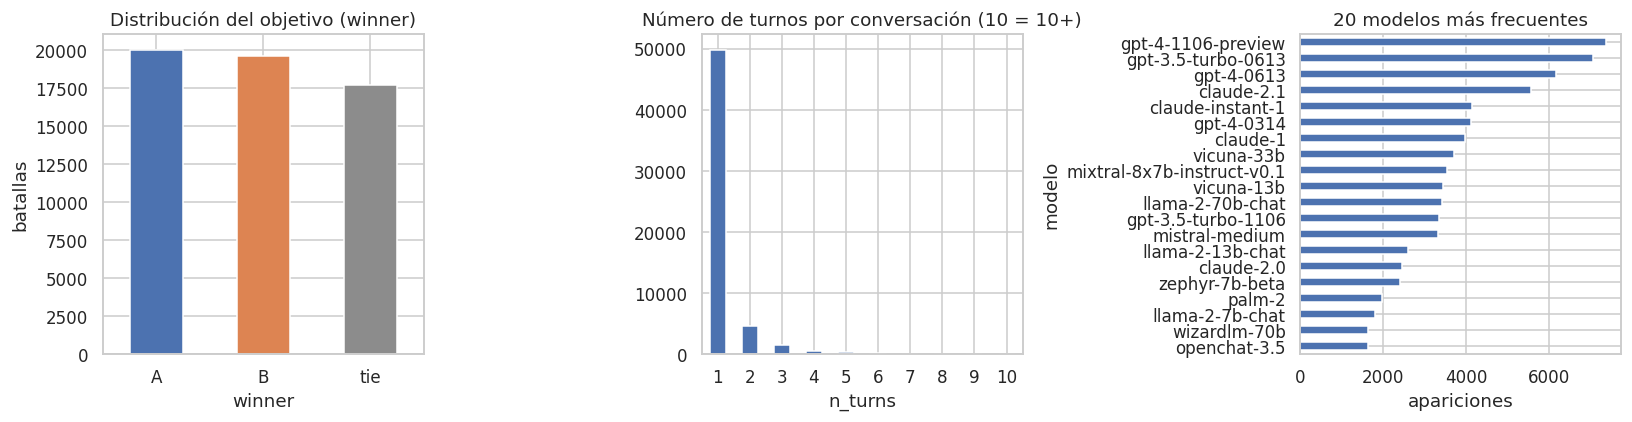

In [23]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
df["winner"].value_counts().plot.bar(ax=ax[0], color=["#4c72b0", "#dd8452", "#8c8c8c"], rot=0)
ax[0].set_title("Distribución del objetivo (winner)"); ax[0].set_ylabel("batallas")
df["n_turns"].clip(upper=10).value_counts().sort_index().plot.bar(ax=ax[1], rot=0)
ax[1].set_title("Número de turnos por conversación (10 = 10+)")
tabla_modelos["frecuencia"].head(20).sort_values().plot.barh(ax=ax[2])
ax[2].set_title("20 modelos más frecuentes"); ax[2].set_xlabel("apariciones")
plt.tight_layout(); plt.show()

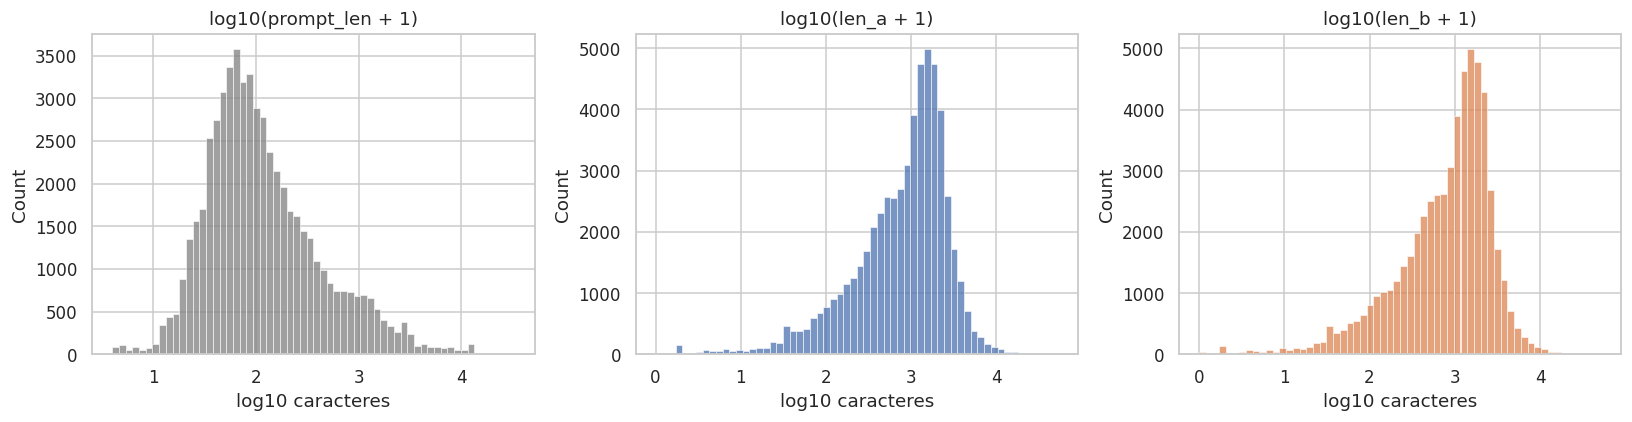

In [24]:
# Histogramas de longitudes (escala log por la fuerte asimetría)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for col, a, c in [("prompt_len", ax[0], "gray"), ("len_a", ax[1], "#4c72b0"), ("len_b", ax[2], "#dd8452")]:
    sns.histplot(np.log10(df[col] + 1), bins=60, ax=a, color=c)
    a.set_title(f"log10({col} + 1)"); a.set_xlabel("log10 caracteres")
plt.tight_layout(); plt.show()

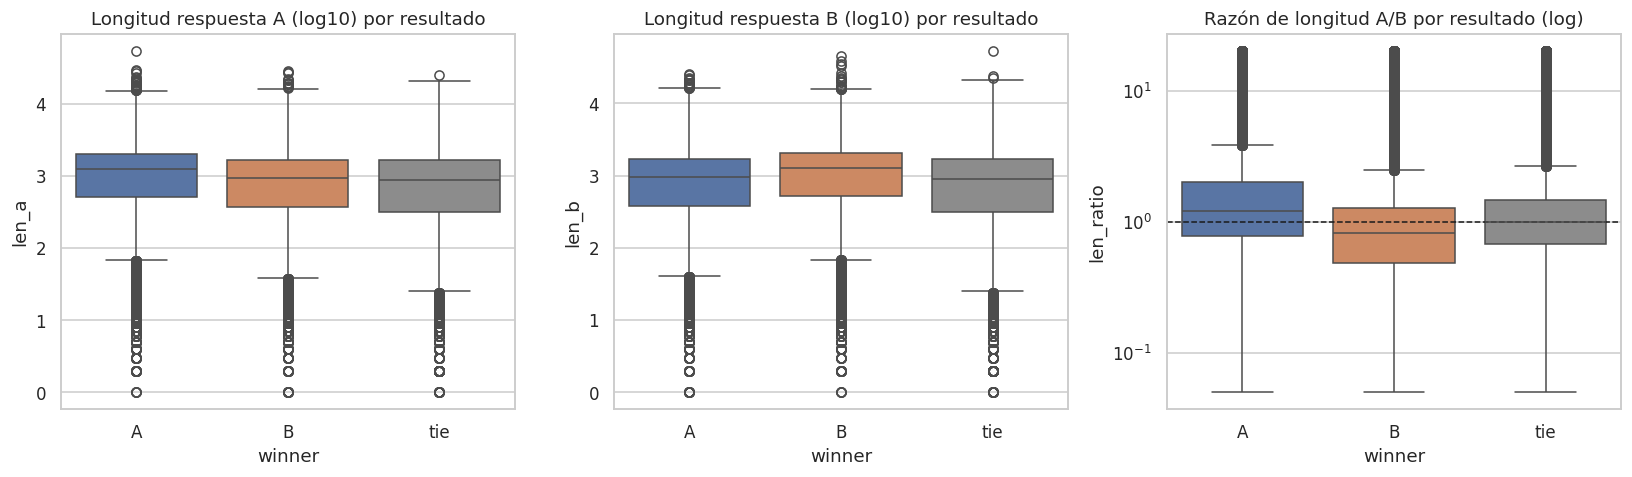

In [25]:
# Diagramas de caja: longitud de cada respuesta según el resultado
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
sns.boxplot(data=df, x="winner", y=np.log10(df.len_a + 1), ax=ax[0], palette=["#4c72b0", "#dd8452", "#8c8c8c"])
ax[0].set_title("Longitud respuesta A (log10) por resultado")
sns.boxplot(data=df, x="winner", y=np.log10(df.len_b + 1), ax=ax[1], palette=["#4c72b0", "#dd8452", "#8c8c8c"])
ax[1].set_title("Longitud respuesta B (log10) por resultado")
sns.boxplot(data=df, x="winner", y=df.len_ratio.clip(0.05, 20), ax=ax[2], palette=["#4c72b0", "#dd8452", "#8c8c8c"])
ax[2].set_yscale("log"); ax[2].axhline(1, ls="--", c="k", lw=1)
ax[2].set_title("Razón de longitud A/B por resultado (log)")
plt.tight_layout(); plt.show()

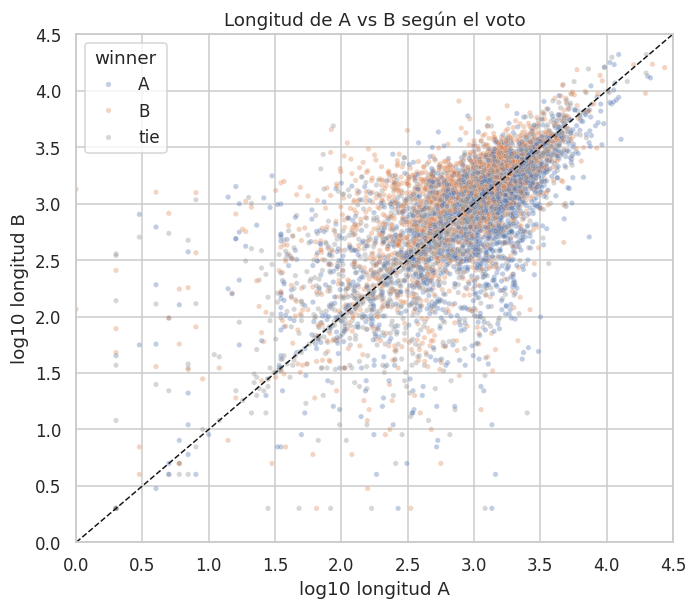

In [26]:
# Dispersión: longitud A vs longitud B coloreada por ganador (muestra aleatoria)
m = df.sample(min(6000, len(df)), random_state=42)
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(data=m, x=np.log10(m.len_a + 1), y=np.log10(m.len_b + 1), hue="winner", alpha=.35, s=12,
                palette={"A": "#4c72b0", "B": "#dd8452", "tie": "#8c8c8c"}, ax=ax)
lim = [0, 4.5]; ax.plot(lim, lim, "k--", lw=1); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("log10 longitud A"); ax.set_ylabel("log10 longitud B"); ax.set_title("Longitud de A vs B según el voto")
plt.show()

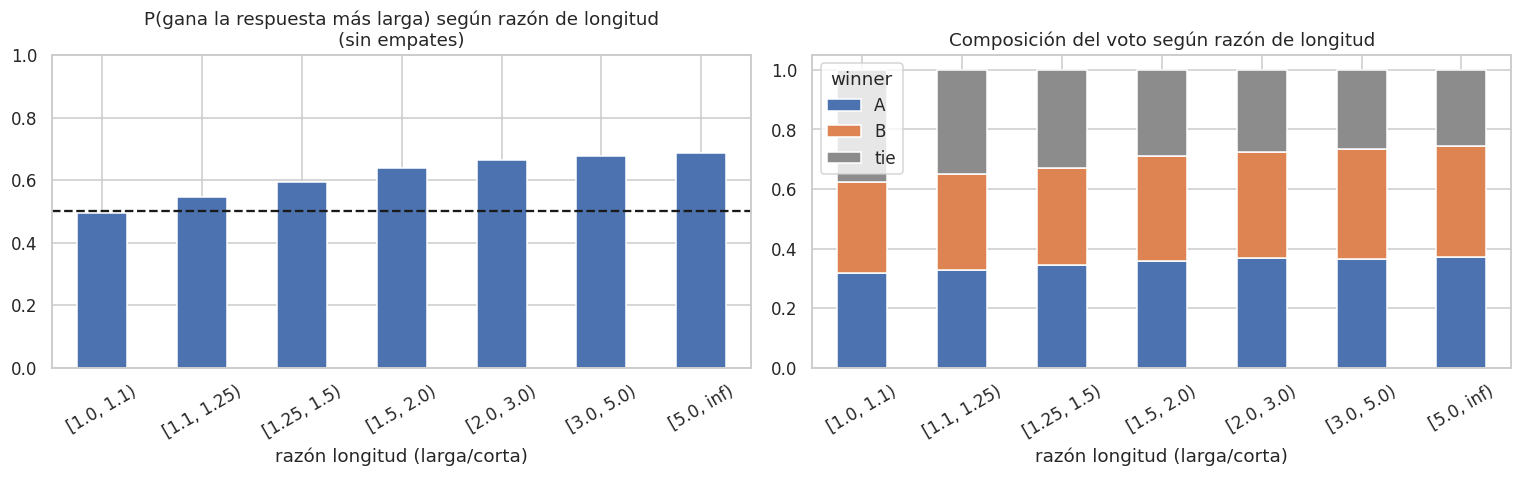

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
tabla_ratio["p(gana la más larga)"].plot.bar(ax=ax[0], rot=30, color="#4c72b0")
ax[0].axhline(0.5, ls="--", c="k"); ax[0].set_ylim(0, 1)
ax[0].set_title("P(gana la respuesta más larga) según razón de longitud\n(sin empates)"); ax[0].set_xlabel("razón longitud (larga/corta)")
df.groupby("abs_ratio_bin")["winner"].value_counts(normalize=True).unstack().plot.bar(stacked=True, ax=ax[1], rot=30,
    color=["#4c72b0", "#dd8452", "#8c8c8c"])
ax[1].set_title("Composición del voto según razón de longitud"); ax[1].set_xlabel("razón longitud (larga/corta)")
plt.tight_layout(); plt.show()

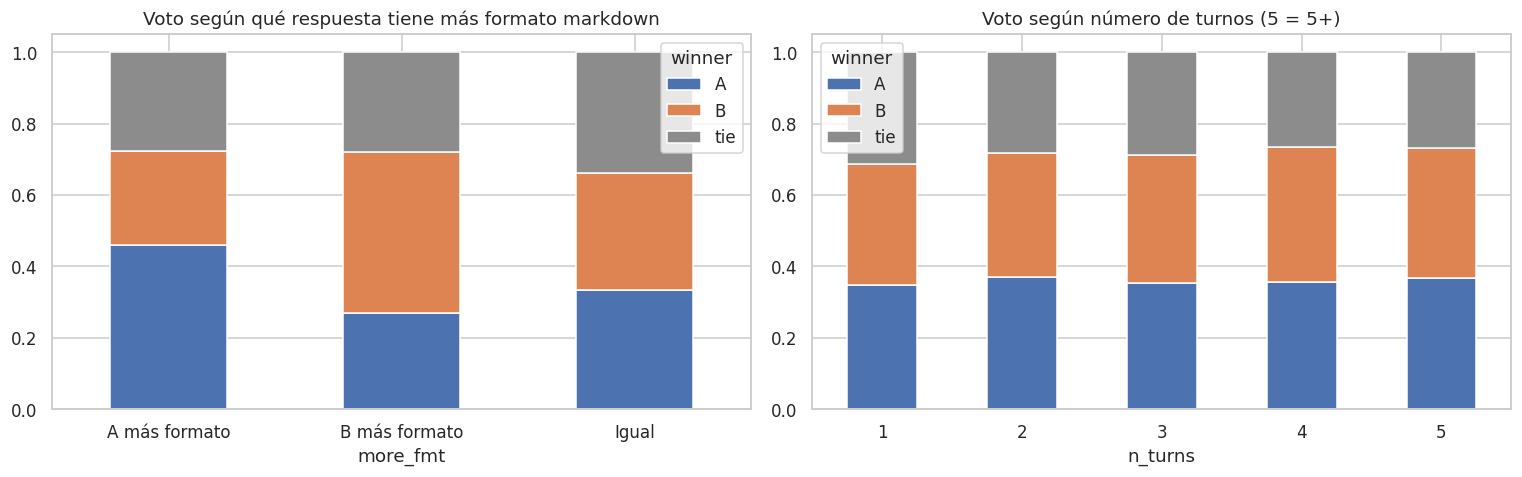

In [28]:
# Formato markdown vs resultado
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
pd.crosstab(df["more_fmt"], df["winner"], normalize="index").plot.bar(stacked=True, ax=ax[0], rot=0, color=["#4c72b0", "#dd8452", "#8c8c8c"])
ax[0].set_title("Voto según qué respuesta tiene más formato markdown")
pd.crosstab(df["n_turns"].clip(upper=5), df["winner"], normalize="index").plot.bar(stacked=True, ax=ax[1], rot=0, color=["#4c72b0", "#dd8452", "#8c8c8c"])
ax[1].set_title("Voto según número de turnos (5 = 5+)")
plt.tight_layout(); plt.show()

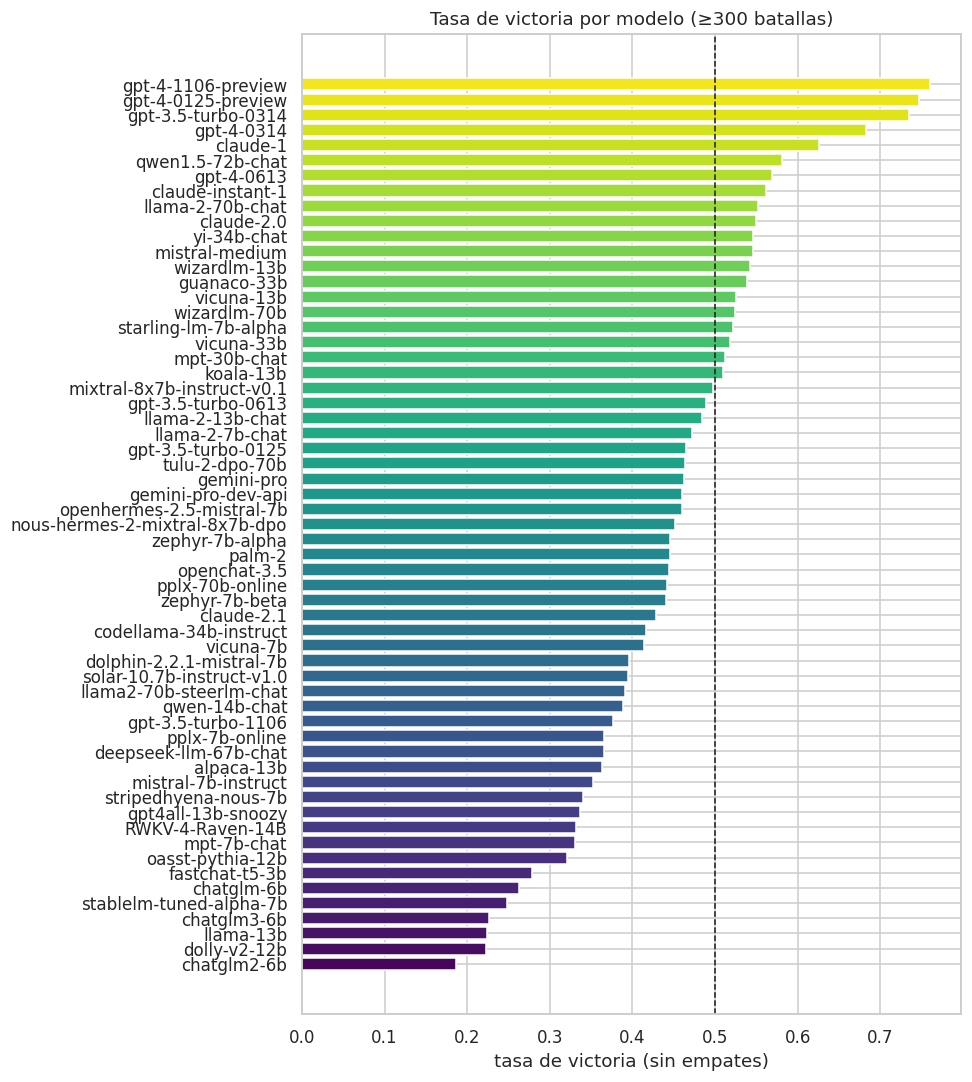

In [29]:
# Tasa de victoria por modelo
fig, ax = plt.subplots(figsize=(9, 10))
wr = winrate.sort_values("tasa_victoria_sin_empates")
ax.barh(wr.index, wr.tasa_victoria_sin_empates, color=sns.color_palette("viridis", len(wr)))
ax.axvline(0.5, ls="--", c="k", lw=1); ax.set_xlabel("tasa de victoria (sin empates)")
ax.set_title("Tasa de victoria por modelo (≥300 batallas)")
plt.tight_layout(); plt.show()

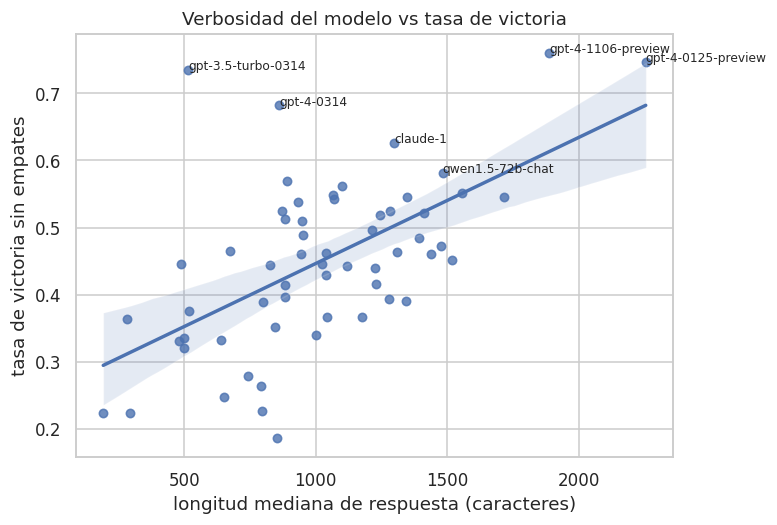

In [30]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(data=winrate, x="long_mediana", y="tasa_victoria_sin_empates", ax=ax, scatter_kws={"s": 30})
for name, r in winrate.head(6).iterrows():
    ax.annotate(name, (r.long_mediana, r.tasa_victoria_sin_empates), fontsize=8)
ax.set_xlabel("longitud mediana de respuesta (caracteres)"); ax.set_ylabel("tasa de victoria sin empates")
ax.set_title("Verbosidad del modelo vs tasa de victoria")
plt.show()

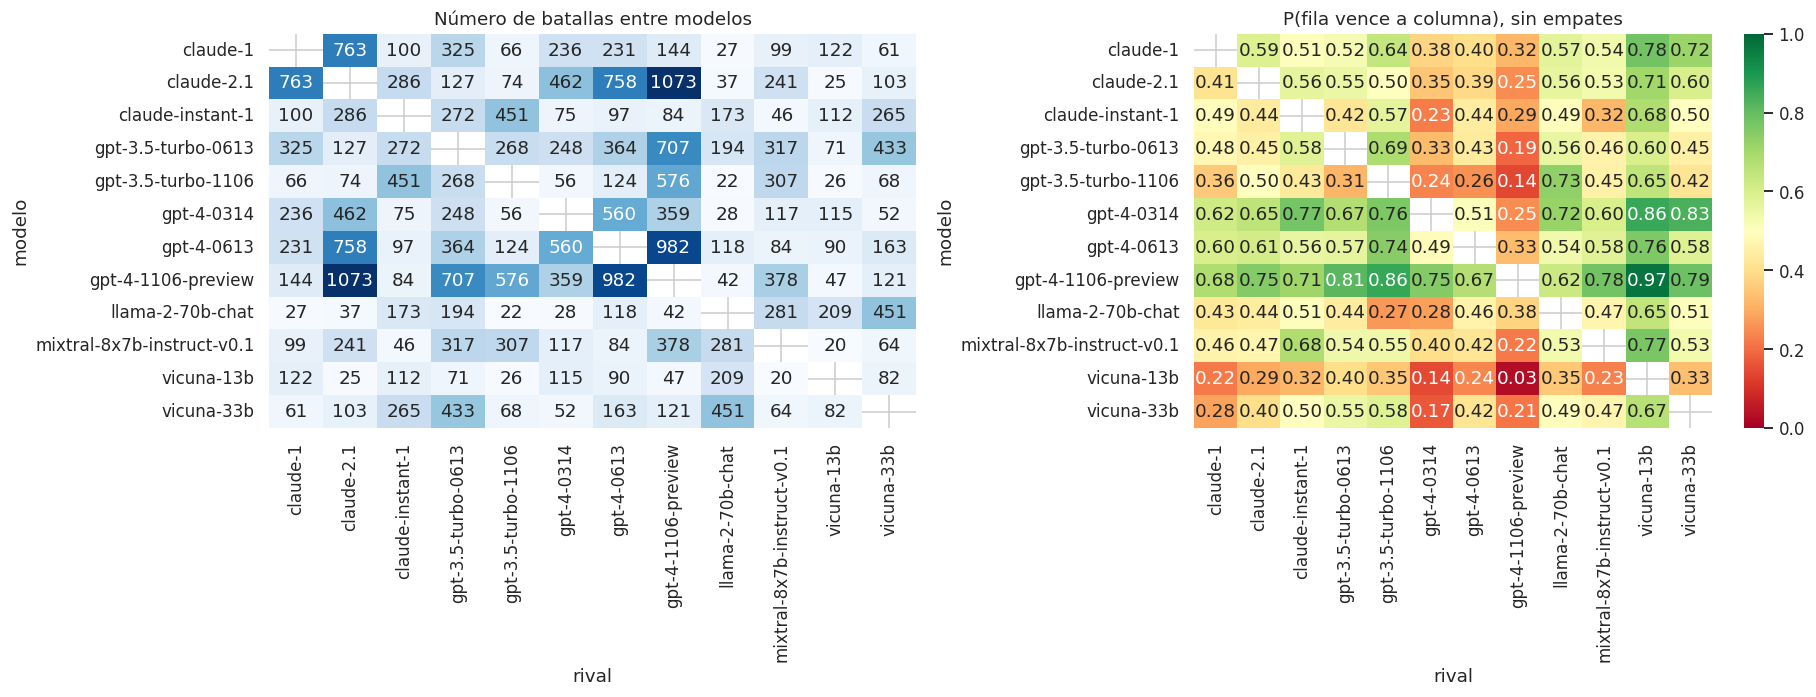

In [31]:
# Matriz de enfrentamientos entre los modelos más frecuentes
top = tabla_modelos.index[:12]
sub = apar.copy()
sub["rival"] = pd.concat([df["model_b"], df["model_a"]]).values
sub = sub[sub.modelo.isin(top) & sub.rival.isin(top) & (sub.modelo != sub.rival)]
mat_n = sub.pivot_table(index="modelo", columns="rival", values="gana", aggfunc="size")
mat_w = sub[~sub.empata].pivot_table(index="modelo", columns="rival", values="gana", aggfunc="mean")
fig, ax = plt.subplots(1, 2, figsize=(17, 6.5))
sns.heatmap(mat_n, annot=True, fmt=".0f", cmap="Blues", ax=ax[0], cbar=False); ax[0].set_title("Número de batallas entre modelos")
sns.heatmap(mat_w, annot=True, fmt=".2f", cmap="RdYlGn", center=0.5, vmin=0, vmax=1, ax=ax[1]); ax[1].set_title("P(fila vence a columna), sin empates")
plt.tight_layout(); plt.show()

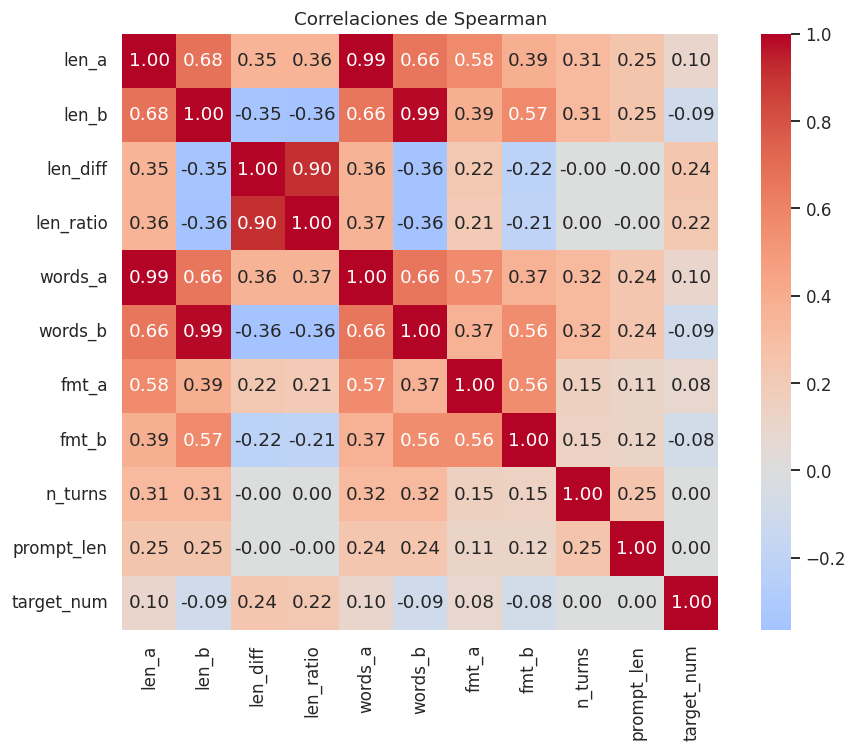

In [32]:
# Mapa de calor de correlaciones (Spearman) entre variables numéricas derivadas
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Correlaciones de Spearman")
plt.tight_layout(); plt.show()

In [33]:
# Outliers: batallas con respuestas extremadamente largas o prompts extremadamente largos
q99 = df[["prompt_len", "len_a", "len_b"]].quantile(0.99)
print("Percentil 99:\n", q99)
extremos = df[(df.len_a > q99.len_a) | (df.len_b > q99.len_b)]
print("\nBatallas con alguna respuesta por encima del p99:", len(extremos))
display(freq(extremos["winner"]))
display(pd.concat([df["model_a"][df.len_a > q99.len_a], df["model_b"][df.len_b > q99.len_b]]).value_counts().head(10))

Percentil 99:
 prompt_len   4,701.400
len_a        6,783.930
len_b        6,736.310
Name: 0.99, dtype: float64

Batallas con alguna respuesta por encima del p99: 822


,frecuencia,proporción
winner,,
A,326,0.397
B,288,0.350
tie,208,0.253


gpt-4-1106-preview            187
gpt-3.5-turbo-0613             71
mistral-medium                 67
llama-2-70b-chat               59
mixtral-8x7b-instruct-v0.1     56
claude-1                       53
gpt-4-0314                     53
claude-2.1                     46
gpt-4-0613                     45
gpt-4-0125-preview             43
Name: count, dtype: int64

**Hallazgos de los gráficos y de los atípicos**

- Los histogramas confirman la asimetría: en escala log las longitudes son aproximadamente normales, con una pequeña acumulación cerca de 0 (respuestas vacías o muy cortas).
- En los diagramas de caja, la respuesta ganadora tiene mediana de longitud claramente mayor (1,241 vs 961 caracteres cuando gana A) y en la razón A/B la mediana se desplaza por encima de 1 cuando gana A y por debajo cuando gana B; los empates se concentran en razón ≈ 1.
- En el gráfico de dispersión los puntos de "gana A" se sitúan por debajo de la diagonal y los de "gana B" por encima, pero con gran solapamiento: la longitud explica una parte del voto, no la mayoría.
- La matriz de enfrentamientos muestra que el ranking es transitivo en general (gpt-4 vence a casi todos) pero con pocas batallas en algunas parejas, lo que hace ruidosas esas celdas.
- Las correlaciones entre variables derivadas del mismo lado son altas (longitud, palabras y formato del mismo lado), lo que sugiere redundancia; con el objetivo las correlaciones son débiles (|ρ| ≤ 0.24).
- Atípicos: 822 batallas tienen una respuesta por encima del percentil 99 (~6,800 caracteres), generadas sobre todo por gpt-4-1106-preview. En ellas la respuesta larga gana más y hay menos empates (25 %). No se eliminan porque son observaciones reales y coherentes con el patrón general; para el modelado se recomienda trabajar con transformaciones logarítmicas o truncar el texto a una longitud máxima.

## Resumen de hallazgos del análisis exploratorio

*(Sección de apoyo para redactar las conclusiones del punto 5; los valores exactos se leen de las salidas anteriores.)*

1. El dataset es limpio (sin faltantes, 7 duplicados, votos consistentes) y balanceado entre las tres clases; la dificultad está en el empate (31 %) y en que toda la información útil está en texto libre.
2. El factor individual más fuerte es la **longitud relativa** de las respuestas (la más larga gana el 61.5 % de las batallas decididas, hasta 69 % con razón ≥ 5), seguido del **formato markdown**. Ambos reflejan sesgos humanos conocidos y serán variables base del modelo.
3. Los **empates** ocurren cuando las respuestas son parecidas en longitud o idénticas, y son menos frecuentes en conversaciones largas o con gran diferencia de longitud.
4. El **sesgo de posición** es leve: A gana 50.5 % de las batallas decididas (p = 0.038), un efecto real pero de ~1 punto porcentual.
5. La **identidad del modelo** explica mucho (tasas de victoria de 0.30 a 0.76) pero no estará disponible en test, por lo que el modelo deberá inferir la calidad desde el texto.
6. Las variables derivadas de longitud/formato tienen correlaciones débiles con el objetivo (|ρ| ≤ 0.24), así que se espera que un modelo basado solo en ellas supere el azar por poco; la siguiente fase debe incorporar representación del contenido (TF‑IDF, embeddings o un modelo de lenguaje fine-tuned como DeBERTa/Gemma) y usar log‑loss multiclase como métrica.